In [9]:
import pandas as pd
import os

# === Correct path for local VS Code (from inside notebooks folder) ===
raw_path = "../data/processed/pubmedqa_cleaned.csv"

print("Current working directory:", os.getcwd())
print("Looking for file at:", raw_path)

if os.path.exists(raw_path):
    df = pd.read_csv(raw_path)
    print(f"✅ SUCCESS! Loaded {len(df)} rows from {raw_path}")
    print("\nColumns:", df.columns.tolist())
    print("\nFirst 5 rows:")
    print(df.head())
else:
    print(f"❌ Still not found: {raw_path}")
    print("\nLet's check what files actually exist:")
    processed_dir = "../data/processed"
    if os.path.exists(processed_dir):
        print("Files in processed folder:", os.listdir(processed_dir))
    else:
        print("Processed folder does not exist!")

Current working directory: c:\Users\Eman\Healthcare-RAG-Powered-Medical-QA-Assistant\notebooks
Looking for file at: ../data/processed/pubmedqa_cleaned.csv
✅ SUCCESS! Loaded 9994 rows from ../data/processed/pubmedqa_cleaned.csv

Columns: ['question', 'context', 'answer', 'category', 'question_word_count', 'answer_word_count', 'context_word_count']

First 5 rows:
                                            question  \
0  Is naturopathy as effective as conventional th...   
1  Can randomised trials rely on existing electro...   
2  Is laparoscopic radical prostatectomy better t...   
3  Does bacterial gastroenteritis predispose peop...   
4  Is early colonoscopy after admission for acute...   

                                             context  \
0  Although the use of alternative medicine in th...   
1  To estimate the feasibility, utility and resou...   
2  To compare morbidity in two groups of patients...   
3  Irritable bowel syndrome (IBS) might develop a...   
4  Urgent colonosco

In [10]:
keywords = {
    'Treatment': ['surgery', 'operation', 'repair', 'procedure'],
    'Medication': ['drug', 'medication', 'antidepressant', 'therapy'],
    'Symptoms': ['symptom', 'sign', 'manifestation', 'impairment'],
    'Diagnosis': ['diagnosis', 'imaging', 'classification', 'biopsy'],
    'Prevention': ['prevention', 'avoid', 'vaccination', 'prophylaxis']
}

In [11]:
def label_row(row):
    text = (str(row['question']) + " " + str(row['context'])).lower()
    for label, words in keywords.items():
        if any(word in text for word in words):
            return label
    return 'General'

In [12]:
df['label'] = df.apply(label_row, axis=1)
df.head(10)

,question,context,answer,category,question_word_count,answer_word_count,context_word_count,label
0,Is naturopathy as effective as conventional th...,Although the use of alternative medicine in th...,Naturopathy appears to be an effective alterna...,Symptoms,12,17,254,Medication
1,Can randomised trials rely on existing electro...,"To estimate the feasibility, utility and resou...",Routine data have the potential to support hea...,General,8,81,364,Treatment
2,Is laparoscopic radical prostatectomy better t...,To compare morbidity in two groups of patients...,The results of our non-randomized study show t...,General,10,30,242,Treatment
3,Does bacterial gastroenteritis predispose peop...,Irritable bowel syndrome (IBS) might develop a...,Symptoms consistent with IBS and functional di...,Diagnosis,9,52,227,Symptoms
4,Is early colonoscopy after admission for acute...,Urgent colonoscopy has been proposed for the d...,No significant association is apparent between...,Symptoms,10,32,189,Medication
5,Does the use of a specialised paediatric retri...,To compare the proportion of airway and vascul...,Referring hospital staff are performing a grea...,General,21,47,153,Treatment
6,Management of thoracic empyema in childhood: d...,To determine the clinical course and long term...,Results suggest that decortication is not nece...,Treatment,11,36,132,General
7,Does repeated hyperbaric exposure to 4 atmosph...,Direct pressure applied on the inner ear canno...,Pressure applied directly on the inner ear dur...,General,11,14,188,Symptoms
8,Lower urinary tract reconstruction for duplica...,Current practice in reconstruction of the lowe...,Lower urinary tract reconstruction for duplica...,General,22,57,178,Diagnosis
9,Is common sheath extravesical reimplantation a...,We evaluate the outcome vesicoureteral reflux ...,Common sheath extravesical reimplantation is h...,General,15,32,284,Treatment


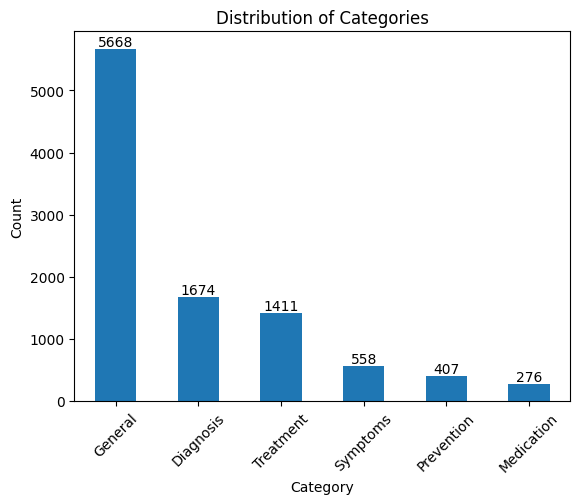

In [13]:
import matplotlib.pyplot as plt

category_counts = df["category"].value_counts().sort_values(ascending=False)

plt.figure()
ax = category_counts.plot(kind='bar')

for i, v in enumerate(category_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [15]:
import pandas as pd
import os

# Save the labeled dataset locally (suitable for VS Code)
output_path = "../data/processed/pubmedqa_cleaned_Labeled.csv"

# Make sure the processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save the dataframe
df.to_csv(output_path, index=False)

print(f"✅ Labeled dataset successfully saved to:")
print(f"   {output_path}")
print(f"   Total rows saved: {len(df)}")

# Optional: Show first few rows to confirm
print("\nFirst 5 rows of labeled data:")
print(df.head())

✅ Labeled dataset successfully saved to:
   ../data/processed/pubmedqa_cleaned_Labeled.csv
   Total rows saved: 9994

First 5 rows of labeled data:
                                            question  \
0  Is naturopathy as effective as conventional th...   
1  Can randomised trials rely on existing electro...   
2  Is laparoscopic radical prostatectomy better t...   
3  Does bacterial gastroenteritis predispose peop...   
4  Is early colonoscopy after admission for acute...   

                                             context  \
0  Although the use of alternative medicine in th...   
1  To estimate the feasibility, utility and resou...   
2  To compare morbidity in two groups of patients...   
3  Irritable bowel syndrome (IBS) might develop a...   
4  Urgent colonoscopy has been proposed for the d...   

                                              answer   category  \
0  Naturopathy appears to be an effective alterna...   Symptoms   
1  Routine data have the potential to suppor